In [1]:
import cmdstanpy as csp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

c:\Users\sebas\one\OneDrive\grive\faks\masters\y2\s1\BayesianStats\BayesianStats\hw3\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("no2.csv")

### Frequency analysis

In [3]:
fs = 365
n = len(df)

In [4]:
X = np.fft.fft(df["no2"])
freq = np.fft.fftfreq(n, d=1/fs)

In [5]:
mask = freq > 0
amp = np.abs(X) / n

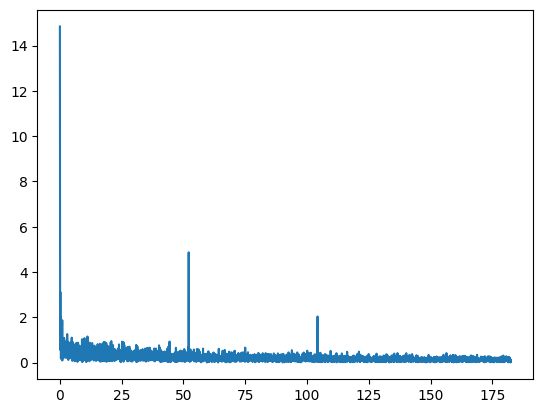

In [6]:
plt.plot(freq[mask], amp[mask])

In [7]:
print(freq[np.argsort(amp)[::-1][:10]])  # top 10 frequencies

seasonality = 365 / 52 # 1 week

[ 0.00000000e+00 -3.51875060e-02  3.51875060e-02  7.03750121e-02
 -7.03750121e-02 -5.21478839e+01  5.21478839e+01 -1.05562518e-01
  1.05562518e-01 -2.11125036e-01]


### Data analysis

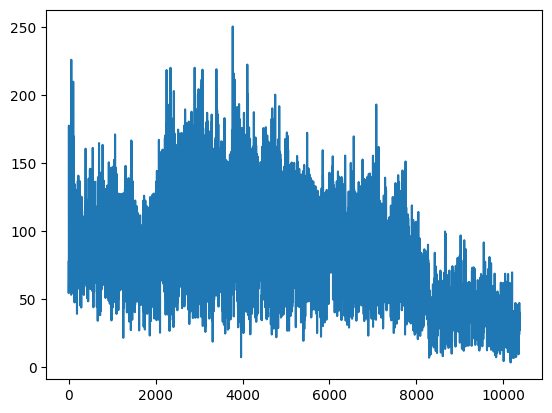

In [8]:
plt.plot(df["no2"])

### Model fitting

In [3]:
csp.install_cmdstan()
csp.rebuild_cmdstan()

CmdStan install directory: C:\Users\sebas\.cmdstan
Installing CmdStan version: 2.37.0
Download successful, file: C:\Users\sebas\AppData\Local\Temp\tmp1_tj4jag
Extracting distribution


18:04:07 - cmdstanpy - WARNING - CmdStan installation failed.
Command "make build" failed
Command: ['mingw32-make', 'build', '-j1']
failed with error [WinError 2] The system cannot find the file specified



Unpacked download as cmdstan-2.37.0
Building version cmdstan-2.37.0, may take several minutes, depending on your system.


CmdStanInstallError: Command "make clean-all" failed
Command: ['mingw32-make', 'clean-all']
failed with error [WinError 2] The system cannot find the file specified


In [10]:
model = csp.CmdStanModel(stan_file="harmonic.stan", force_compile=True)

17:48:57 - cmdstanpy - INFO - compiling stan file C:\Users\sebas\one\OneDrive\grive\faks\masters\y2\s1\BayesianStats\BayesianStats\hw3\harmonic.stan to exe file C:\Users\sebas\one\OneDrive\grive\faks\masters\y2\s1\BayesianStats\BayesianStats\hw3\harmonic.exe


ValueError: Failed to compile Stan model 'C:\Users\sebas\one\OneDrive\grive\faks\masters\y2\s1\BayesianStats\BayesianStats\hw3\harmonic.stan'. Console:

Command: ['mingw32-make', 'STANCFLAGS+=--filename-in-msg=harmonic.stan', 'C:/Users/sebas/one/OneDrive/grive/faks/masters/y2/s1/BayesianStats/BayesianStats/hw3/harmonic.exe']
failed with error [WinError 2] The system cannot find the file specified



In [ ]:
df["day"] = df.index + 1

In [ ]:
stan_data = {
    "n": len(df),
    "t": df["day"],
    "y": df["no2"],
    "k": 1,
    "omega": 2 * np.pi / seasonality
}

In [ ]:
fit = model.sample(
    data=stan_data,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=42,
    show_console=True
)

17:47:40 - cmdstanpy - INFO - Chain [1] start processing
17:47:40 - cmdstanpy - INFO - Chain [2] start processing
17:47:40 - cmdstanpy - INFO - Chain [3] start processing
17:47:40 - cmdstanpy - INFO - Chain [4] start processing


RuntimeError: Error during sampling:

Command and output files:
RunSet: chains=4, chain_ids=[1, 2, 3, 4], num_processes=4
 cmd (chain 1):
	['C:\\Users\\sebas\\one\\OneDrive\\grive\\faks\\masters\\y2\\s1\\BayesianStats\\BayesianStats\\hw3\\harmonic.exe', 'id=1', 'random', 'seed=42', 'data', 'file=C:\\Users\\sebas\\AppData\\Local\\Temp\\tmpjvnz3qg2\\9fo9htsu.json', 'output', 'file=C:\\Users\\sebas\\AppData\\Local\\Temp\\tmpjvnz3qg2\\harmonic__e1510p\\harmonic-20260103174740_1.csv', 'method=sample', 'num_samples=1000', 'num_warmup=1000', 'algorithm=hmc', 'adapt', 'engaged=1']
 retcodes=[-1, -1, -1, -1]
 per-chain output files (showing chain 1 only):
 csv_file:
	C:\Users\sebas\AppData\Local\Temp\tmpjvnz3qg2\harmonic__e1510p\harmonic-20260103174740_1.csv
 console_msgs (if any):
	C:\Users\sebas\AppData\Local\Temp\tmpjvnz3qg2\harmonic__e1510p\harmonic-20260103174740_0-stdout.txt